Dependencias

In [1]:
import numpy as np
import jax
from jax import numpy as jnp
import matplotlib.pyplot as plt

1. Análisis del conjunto de datos

In [2]:
data = np.load("../SolucionReferencia_0000/datos_0000.npz")


In [3]:
data.files

['X', 'y', 't', 'meta']

In [4]:
X = data['X'] # f(t), lectura de señal
y = data['y'] # categorías en {0, 1, 2}
t = data['t'] # tiempo t para cada f(t)
meta = data['meta'] # metadata del dataset

In [5]:
y = np.array(y)
ceros = np.where(y == 0)
ceros

(array([ 2,  3,  4,  5, 10, 14, 16, 20]),)

In [6]:
unos = np.where(y == 1)
unos

(array([ 6,  7,  9, 11, 13, 15, 18, 23]),)

In [7]:
dos = np.where(y == 2)
dos

(array([ 0,  1,  8, 12, 17, 19, 21, 22]),)

In [8]:
t.shape, X.shape

((256,), (24, 256))

In [9]:
y.shape

(24,)

Hay 256 muestras de tiempo en total y 45 señales. Son 15 señales por régimen {0, 1, 2}

In [10]:
X[0].shape

(256,)

Vemos que:
$$
X = \left\{\{f_i(t_j)\mid 0\le j<256\}\mid 0\le i<N\right\}
$$

donde:

$$
f_i(t)=\sum_j a_j \cos\left(\omega(k_j)t+\phi_j\right)
$$

y además:

$$
X=X_0\cup X_1\cup X_2
$$

Podemos entrenar una red que tome una señal $f_i(t)$ y tenga como salida una $\hat{y}$ tal que:

$$\hat{y} \approx f_i$$

Las características que se piden para la red son:

1. Ser construida en JAX
2. Recibir una señal $x \in \mathbb{R}^{256}$ (la señal en las 256 muestras de tiempo)
3. Tomar MSE como función de pérdida
4. Usar dos capas:
  - Capa lineal 256 $→$ 2K seguida de una capa de activación (tangente hiperbólica)
  - Capa lineal 2K $→$ 256 que reconstruye la señal

    con K = 20 frecuencias.
5. Inicializar pesos de la red con la matriz de Fourier y aleatoriamente, para posteriormente comparar.

El modelo es una implementación simple de un autoencoder. Busca reducir la dimensionalidad de 256 muestras en un espacio latente de 2K variables, donde 2K $\ll
$ 256.

Se necesita un operando $W_1$ tal que $W_1x$ $\in \mathbb{R}^{2k}$, de esta manera:

$$\therefore W_1 \in \mathbb{R}^{2k \times 256}$$

Aplicando la misma lógica para $W_2$:

$$\therefore W_2 \in \mathbb{R}^{256 \times 2k}$$

In [11]:
k = 25
lr = 0.05
epochs = 3000
key = jax.random.key(1713)
key1, key2 = jax.random.split(key)
train = 0

Se nos propone inicializar unos pesos como la matriz de Fourier. Esta matriz, a priori definida con números imaginarios, aplica la Transformada de Fourier a un vector. La transformada de Fourier descompone una señal en un conjunto de frecuencias, pues la redefine en términos de funciones senoidales y cosenoidales simples.

Esta base tiene sentido para nuestro problema, pues si queremos reducir la señal a un conjunto de 40 frecuencias, una matriz de Fourier $\in \mathbb{R}^{40 \times 256}$ nos proporciona por fila un conjunto de ondas de la forma:

$$[sin(2πkt_i)]_{0 \le i < N} \space ó \space [cos(2πkt_i)]_{0 \le i < N}$$

Esto es, una única frecuencia evaluada en los mismos tiempos que las señales de nuestro conjunto de datos.

In [12]:
diff = t[3]-t[2]
diff

np.float64(0.00390625)

In [13]:
c = 0
for i in range(len(t)-1):
  if t[i+1]-t[i] != diff:
    print("El conjunto de muestras de tiempo no está equiespaciado")
    c+=1
    break

if c==0:
  print("El conjunto de muestras de tiempo está equiespaciado")

El conjunto de muestras de tiempo está equiespaciado


In [14]:
np.min(t), np.max(t)

(np.float64(0.0), np.float64(0.99609375))

Como el conjunto de datos de tiempo está equiespaciado y normalizado, podemos usarlo directamente.

In [15]:
def matrixFourier(k):
  filas = []

  for i in range(1, k+1):

    filas.append(jnp.sin(2 * jnp.pi * i * t))
    filas.append(jnp.cos(2 * jnp.pi * i * t))

  return jnp.stack(filas)

fourier = matrixFourier(k)
fourier.shape

(50, 256)

In [16]:
np.min(fourier[0]), np.max(fourier[0]) #tiene la amplitud de seno y coseno de la forma af(x) con a = 1

(Array(-1., dtype=float32), Array(1., dtype=float32))

Energía media del dataset:

In [17]:
eme = (X**2).mean()
round(eme, 3)

np.float64(0.678)

In [18]:
#parámetros aleatorios
params = (jax.random.normal(key1, (2*k, 256)), #W1
          jax.random.normal(key2, (256, 2*k))) #W2

#parámetros con W1 una matriz de Fourier
fparams = (fourier, #W1
          jax.random.normal(key2, (256, 2*k))) #W2

In [19]:
def mse(param, y):
  ygorrito = autoencoder(param, y)
  return jnp.mean((ygorrito - y)**2)
mse = jax.jit(mse)
#jit convierte la función a una composición de operaciones primitivas y se lo envía a XLA para que optimice y compile.

def autoencoder(params, x, tanh=True, freeze_W1=False):
  W1, W2 = params
  if freeze_W1:
    W1 = jax.lax.stop_gradient(W1)
  capa1 = W1 @ x
  act1 = jnp.tanh(capa1) if tanh else capa1
  ygorrito = W2 @ act1
  return ygorrito

Evaluemos la función de error en los pesos inicializados:

In [20]:
mse0 = mse(params, X[train])
mse0

Array(46.391167, dtype=float32)

In [21]:
fmse0 = mse(fparams, X[train])
fmse0

Array(43.043453, dtype=float32)

Un número considerablemente elevado con las bases aleatorias, pues todavía no hemos iniciado el entrenamiento. Por otro lado, un número menor a 10 para la base matriz de Fourier, es claro que los parámetrps, sin haber sido entrenados, ya facilitan el trabajo del autoencoder. Sigue existiendo error porque $W_2$ se instancia aleatoriamente.

Ahora configuremos el entrenamiento:

Necesitamos los pesos (params), la señal (x) y una constante (en este caso) que controle la magnitud del cambio de los pesos (lr).

Una vez definidas las variables, se procede a calcular el gradiente de la función de pérdida, y a ajustar los pesos proporcionalmente.



In [22]:
grad_mse = jax.grad(mse)
grad_mse

<function __main__.mse(param, y)>

In [23]:
@jax.jit #redujo el tiempo de entramiento 96x!
def entrenar(params, x, lr):
  grads = grad_mse(params, x)
  W1, W2 = params
  dW1, dW2 = grads
  W1 = W1 - lr * dW1
  W2 = W2 - lr * dW2
  return (W1, W2)

Ejecutemos un primer paso:

In [24]:
cparams = tuple(x.copy() for x in params) #W1 aleatoria
nW1, nW2 = entrenar(cparams, X[train], lr)

In [25]:
cfparams = tuple(x.copy() for x in fparams) #W1 matriz de Fourier
fnW1, fnW2 = entrenar(cfparams, X[train], lr)

Evaluemos la función de pérdida con estos nuevos pesos:

In [26]:
mse1 = mse((nW1, nW2), X[0])

delta = mse0 - mse1
delta

Array(2.1936874, dtype=float32)

In [27]:
fmse1 = mse((fnW1, fnW2), X[0])

delta = fmse0 - fmse1
delta

Array(2.176056, dtype=float32)

El primer paso de entrenamiento redujo el error con los parámetros aleatorios por 4.28 puntos aproximados, en cambio, incrementó el error por casi 22 puntos para la matriz de Fourier. Puede deberse a la magnitud del $lr$, que de ser grande, genere cambios bruscos en los pesos. Si se reduce el $lr$, efectivamente el primer paso no resulta tan grave, pero las consecuencias son las de alargar el entrenamiento para compensar los cambios menos pronunciados o de terminar con un MSE mayor.

In [28]:
errorRelativo = lambda x, x_hat: np.linalg.norm(x - x_hat) / np.linalg.norm(x)

In [29]:
def trainEpochs(epochs, params, x, lr, debug = False, errRel = False):

  mses = list()
  if errRel:
    rels = np.empty(epochs)

  cparams = tuple(p.copy() for p in params)
  old_mse = mse(cparams, x)
  for i in range(epochs):
    cparams = entrenar(cparams, x, lr)

    new_mse = mse(cparams, x)
    mses.append(new_mse)
    old_mse = new_mse
    rels[i] = errorRelativo(x, autoencoder(cparams, x))

    if (i+1)%100 == 0 and debug:
      print(f'Epoch no. {i+1}:\nMSE: {new_mse}\nDelta: {old_mse-new_mse}\n')

  if not errRel:
    return cparams, mses
  else:
    return cparams, mses, rels

In [30]:
[ceros[0], unos[0], dos[0]]

[array([ 2,  3,  4,  5, 10, 14, 16, 20]),
 array([ 6,  7,  9, 11, 13, 15, 18, 23]),
 array([ 0,  1,  8, 12, 17, 19, 21, 22])]

In [31]:
import random
signals = (
    X[int(random.choice(ceros[0]))],
    X[int(random.choice(unos[0]))],
    X[int(random.choice(dos[0]))]
)

In [32]:
randomParams = list()
fourierParams = list()

randomMses = list()
fourierMses = list()

random_errRels = np.empty((len(signals), epochs))
fourier_errRels = np.empty((len(signals), epochs))

for i, signal in enumerate(signals):
  randomWeights, randomMse, random_errRel = trainEpochs(epochs, params, signal, lr, errRel = True)
  fourierWeights, fourierMse, fourier_errRel = trainEpochs(epochs, fparams, signal, lr, errRel = True)

  randomParams.append(randomWeights)
  fourierParams.append(fourierWeights)

  randomMses.append(randomMse)
  fourierMses.append(fourierMse)

  random_errRels[i] = random_errRel
  fourier_errRels[i] = fourier_errRel

  #random_errRels = np.append(random_errRels, np.array(random_errRel))
  #fourier_errRels = np.append(fourier_errRels, np.array(fourier_errRel))

#de esta manera, randomParams[i] son los parámetros de la señal de régimen i y base aleatoria, lo mismo con mses


Veamos las gráficas de MSE en escala semilogarítmica para cada una de las señales entrenadas, comparando la inicialización aleatoria y la inicialización con la matriz de Fourier.

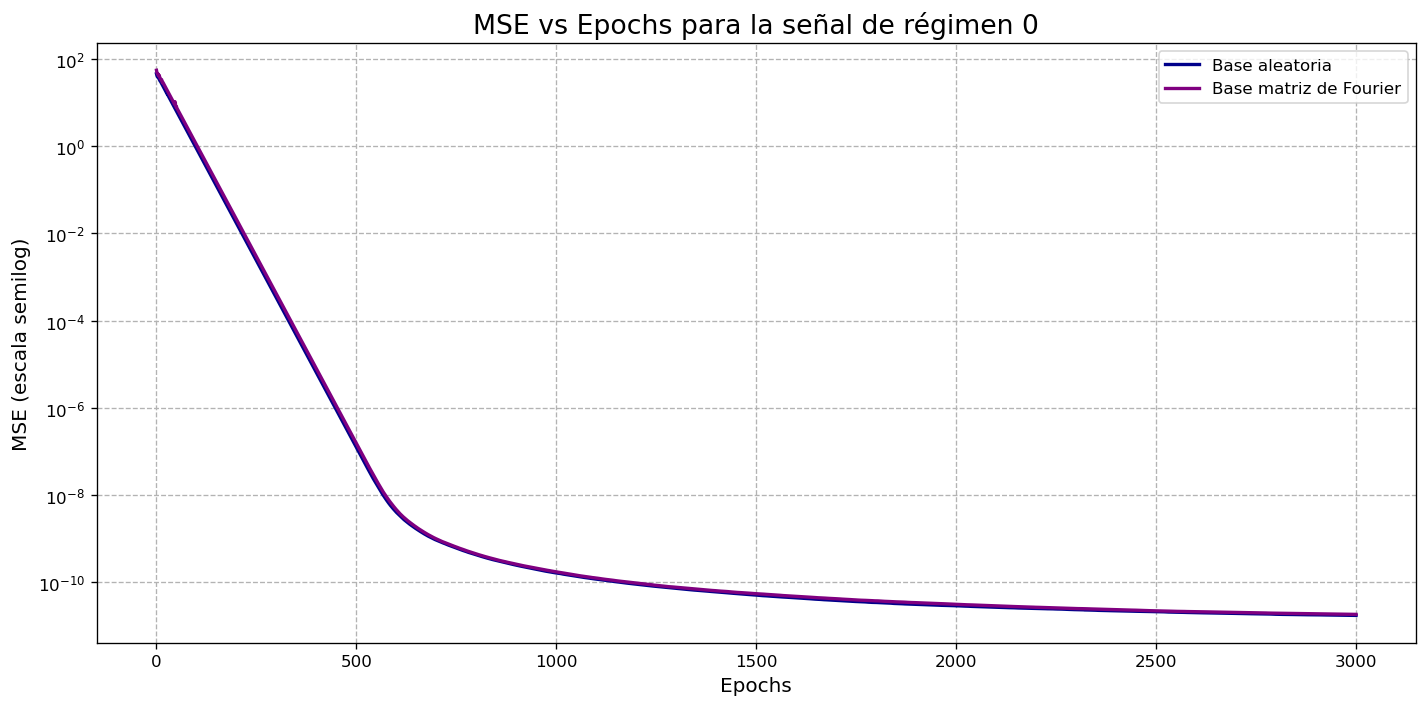

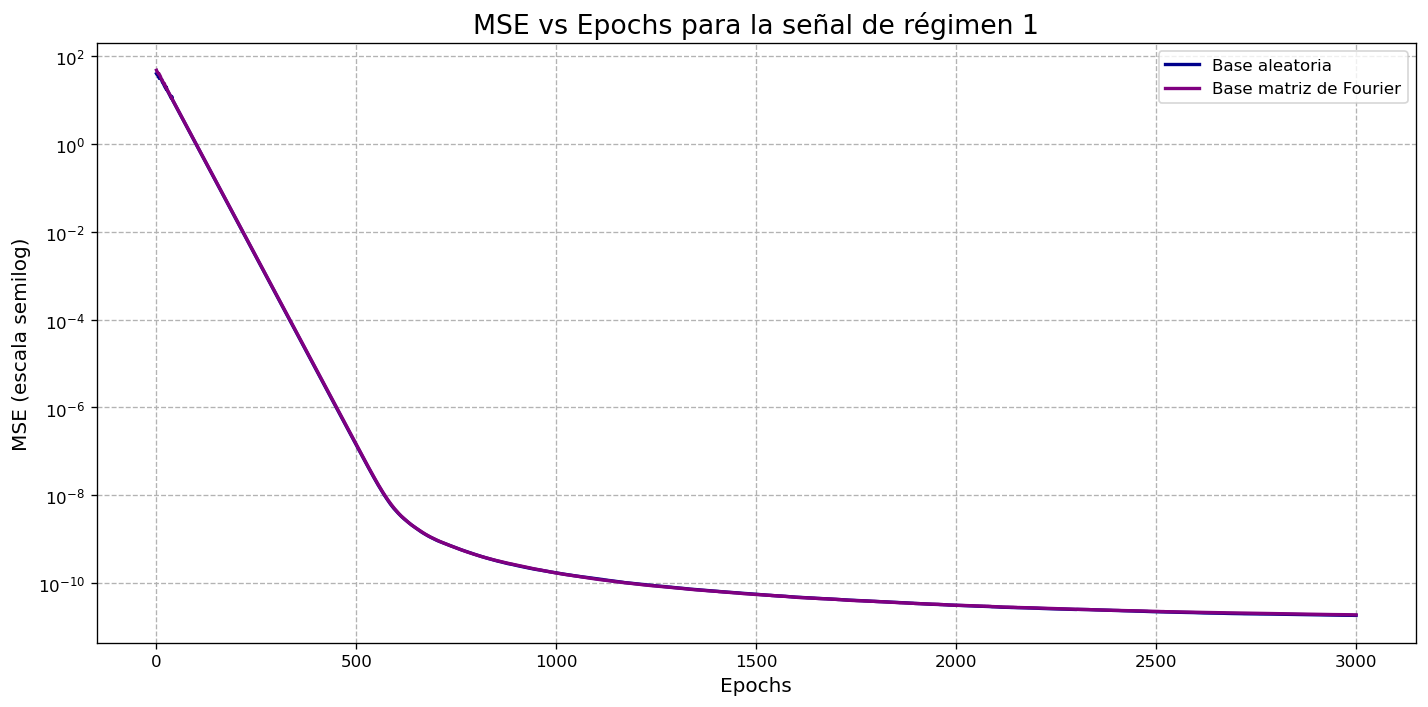

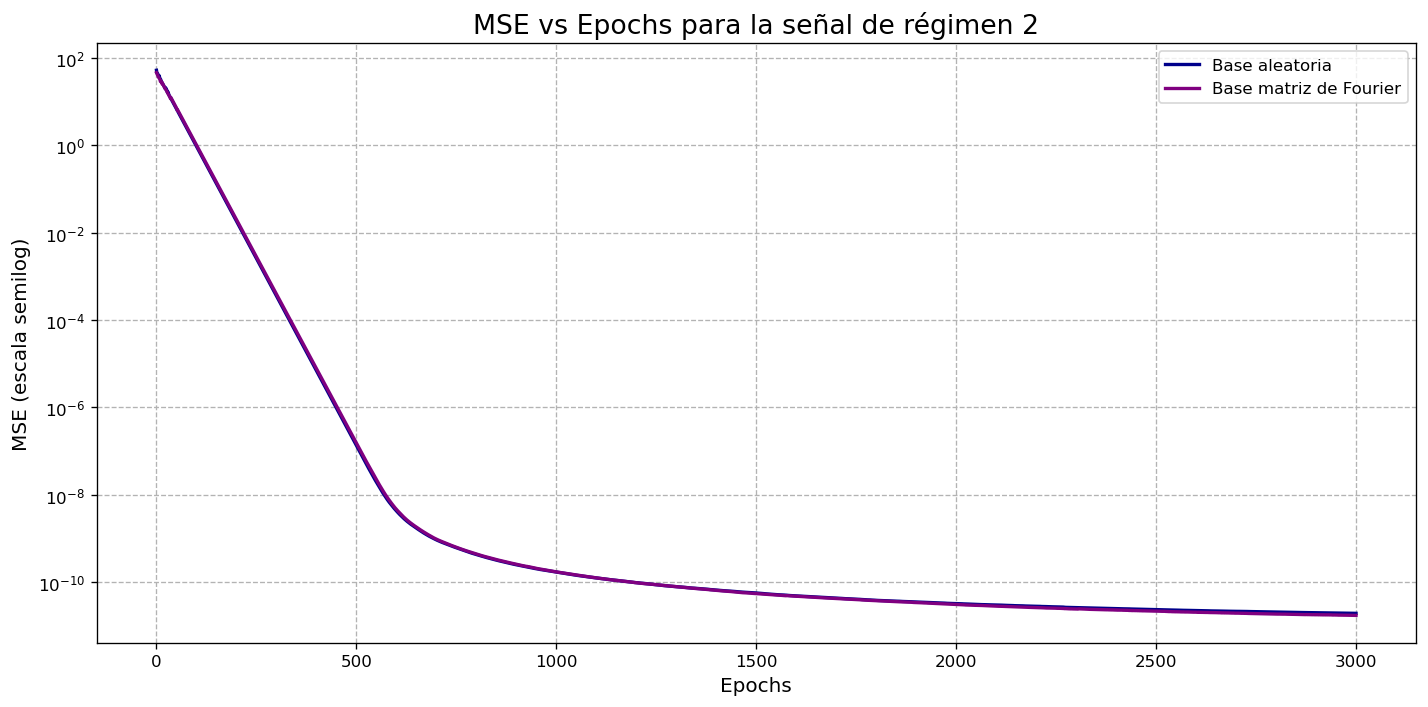

In [33]:
import matplotlib.pyplot as plt

for i in range(len(randomMses)):
    plt.figure(figsize=(12, 6), dpi=120)
    plt.title(f"MSE vs Epochs para la señal de régimen {i}", fontsize=16)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel("MSE (escala semilog)", fontsize=12)

    plt.semilogy(randomMses[i], color='darkblue', linewidth=2, label = "Base aleatoria")
    plt.semilogy(fourierMses[i], color='purple', linewidth=2, label = "Base matriz de Fourier")

    plt.legend()
    plt.grid(True, which="both", ls="--", c='0.7')
    plt.tight_layout()
    plt.show()

Particularmente para el régimen 0, existe una superposición inicial prácticamente completa, conforme avanzan las épocas, la base aleatoria tiende ligeramente a un menor error que la base de Fourier. La diferencia es apenas perceptible.

Si se cambia $lr$ de 0.1 a 0.01 y se usan 40.000 épocas en vez de 4.000, empiezan a verse unas diferencias: a la base de Fourier le va mejor en el régimen 0, aunque no por mucho, y la velocidad de convergencia es mayor con la base aleatoria, alcanzando cifras significativas en los regímenes 1 y 2. El error relativo para el régimen 0 se mantiene bajo (múltiplos de $10^{-7}$) pero se dispara en los regímenes 1 y 2 (múltiplos de $10^{-2}$), mostrando que a medida que el medio se vuelve más dispersivo, se vuelve menos predecible.

Es curioso que ambos modelos parecen responden mejor a $lr$s mayores, llegando incluso a funcionar con un $lr=3$.

El mayor problema que tiene la matriz de Fourier es que una vez empieza a cambiar de valores por el gradiente descendiente, pierde toda la ventaja frente a la base aleatoria, tal vez con otro optimizador o función de pérdida podría aprovechar esa ventaja.

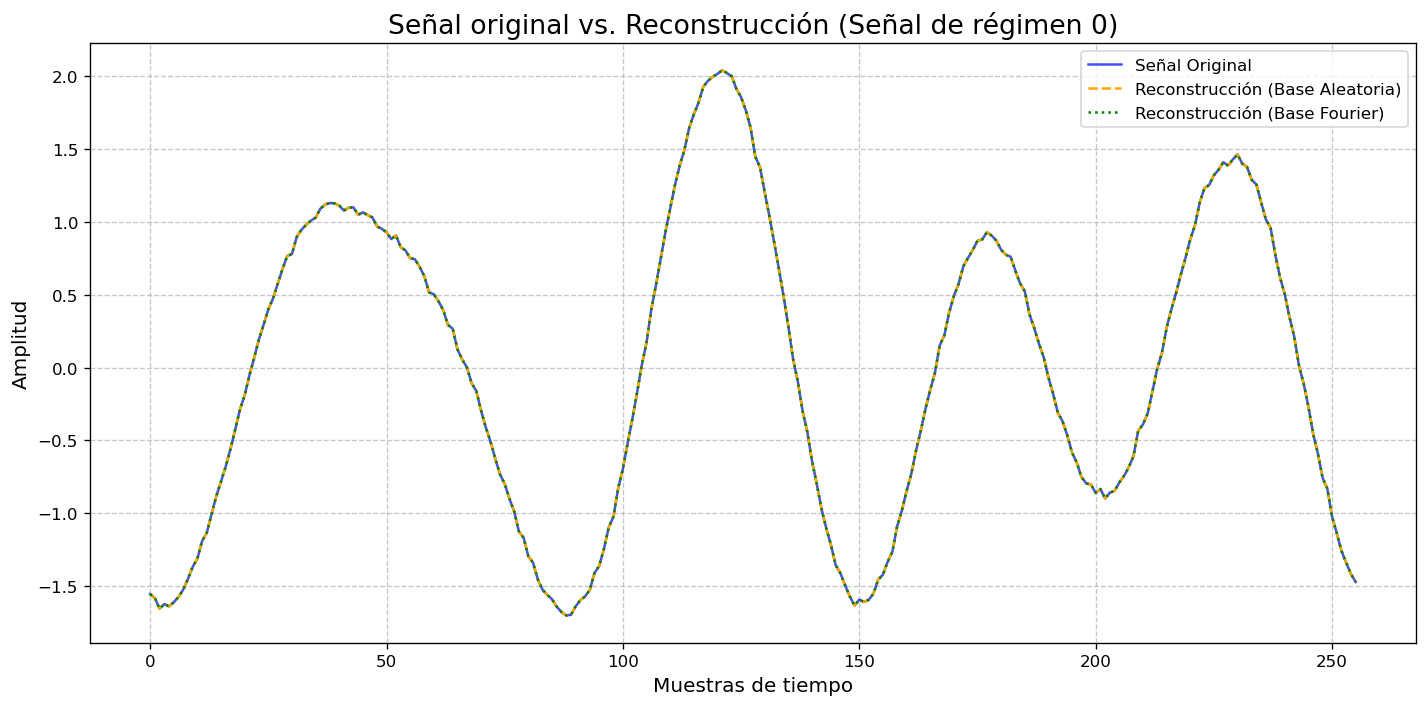

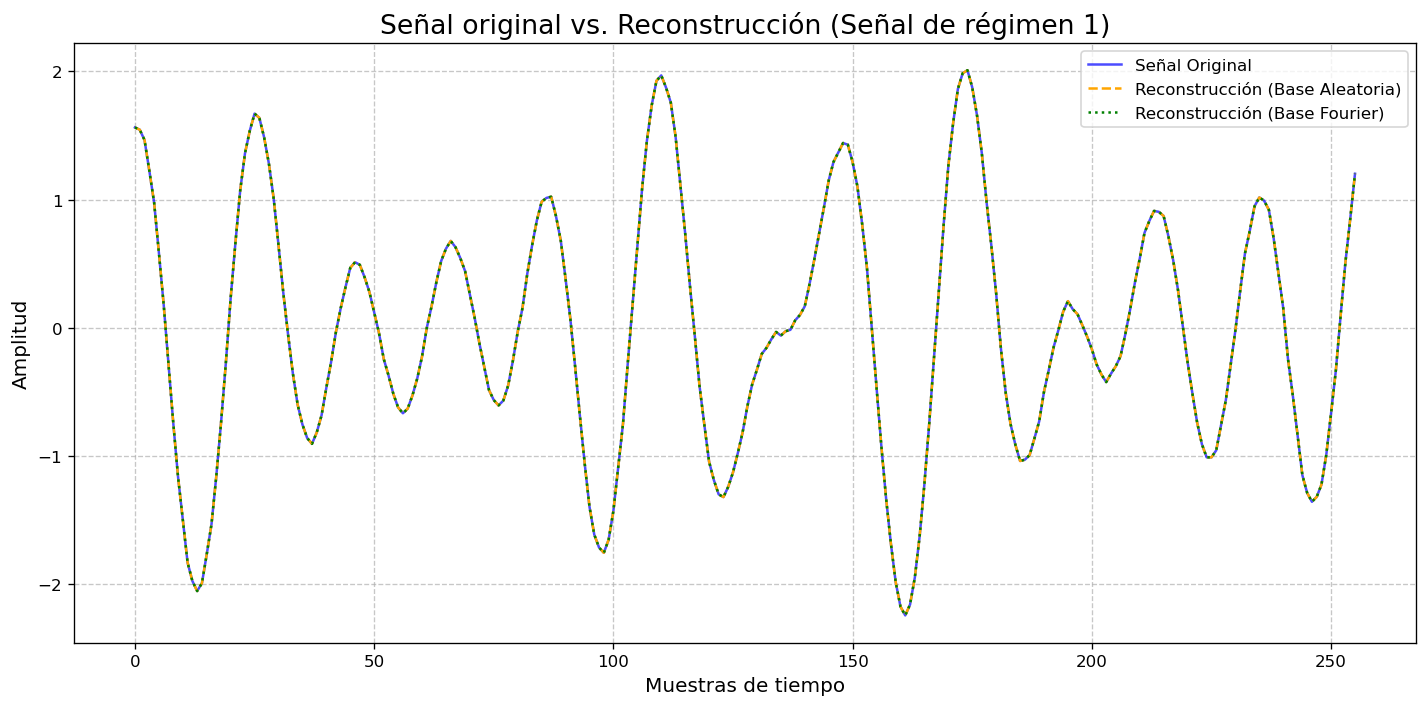

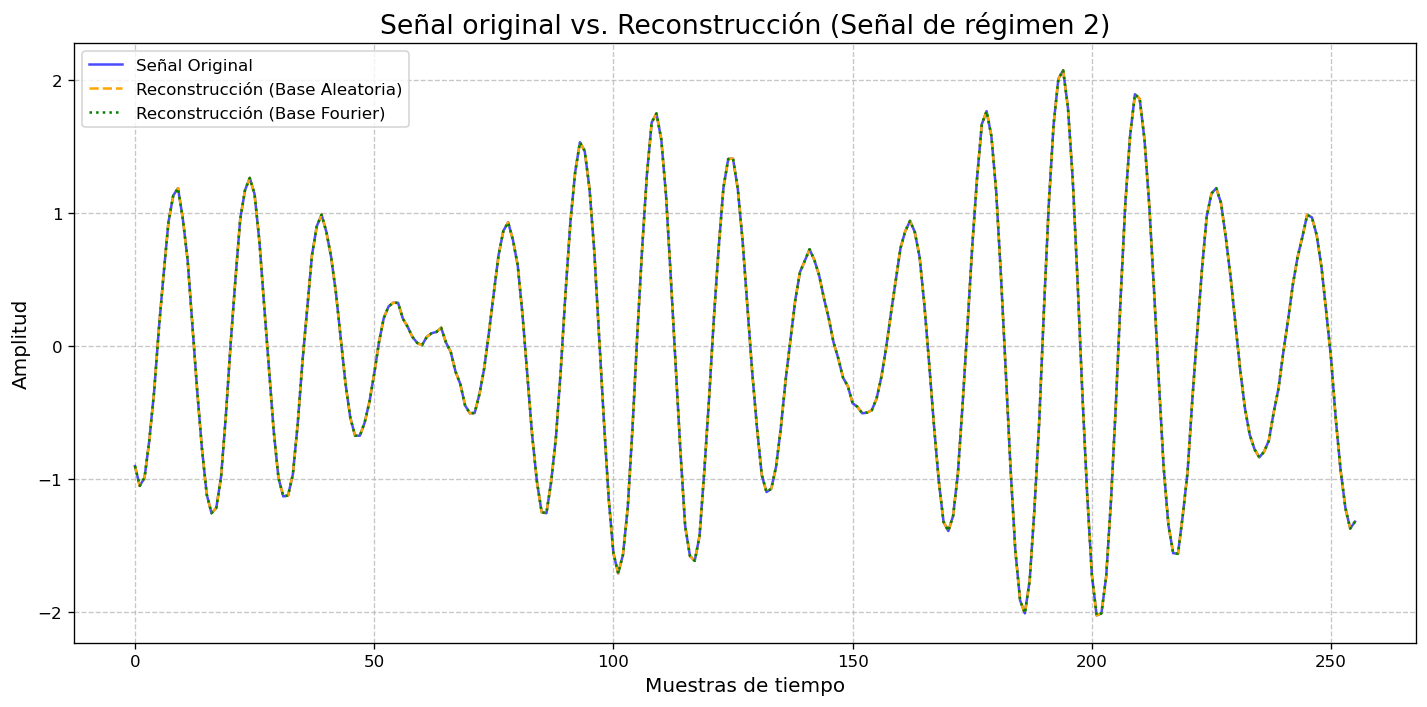

In [34]:
for i, signal in enumerate(signals):
    plt.figure(figsize=(12, 6), dpi=120)
    plt.title(f"Señal original vs. Reconstrucción (Señal de régimen {i})", fontsize=16)
    plt.xlabel("Muestras de tiempo", fontsize=12)
    plt.ylabel("Amplitud", fontsize=12)

    # Original signal
    plt.plot(signal, label='Señal Original', color='blue', alpha=0.7)

    # Reconstruction with random parameters
    reconstructed_random = autoencoder(randomParams[i], signal)
    plt.plot(reconstructed_random, label='Reconstrucción (Base Aleatoria)', color='orange', linestyle='--')

    # Reconstruction with Fourier parameters
    reconstructed_fourier = autoencoder(fourierParams[i], signal)
    plt.plot(reconstructed_fourier, label='Reconstrucción (Base Fourier)', color='green', linestyle=':')

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

No parece existir una ventaja de la base de Fourier sobre la aleatoria, al menos para este caso específico. La evolución de la función de pérdida es prácticamente la misma desde el inicio, y ambas bases terminan siendo capaces de recrear la señal con el autoencoder. Esto se puede deber a varias razones:

- Las señales pueden tener un ruido no tan significativo y las redes encuentran los parámetros ideales rápidamente

- La red es lo suficientemente compleja como para poder describir la señal con menos parámtros, incluso con una base aleatoria.

- La no linearidad inducida por la función de activación $tanh(x)$ es esencial para ambas bases, sin ella, no solo no tienen forma de reducir el error, sino que crece con cada época.

- Se combina una cantidad considerable de frecuencias (k) y una cantidad grande de épocas, se puede contrarrestar una falta de frecuencias con más entrenamiento, o pocas épocas con más frecuencias, en este caso, existen las dos. Aumentar las iteraciones ya no cambia significativamente el MSE.

In [35]:
import numpy as np

for i, signal in enumerate(signals):
    print(f"Error relativo para la señal de régimen {i}:")
    print(f"Base aleatoria: {errorRelativo(signal, autoencoder(randomParams[i], signal))}")
    print(f"Base matriz de Fourier: {errorRelativo(signal, autoencoder(fourierParams[i], signal))}\n")

Error relativo para la señal de régimen 0:
Base aleatoria: 4.023549593399335e-06
Base matriz de Fourier: 4.135319312190563e-06

Error relativo para la señal de régimen 1:
Base aleatoria: 4.448374199946206e-06
Base matriz de Fourier: 4.512586203111413e-06

Error relativo para la señal de régimen 2:
Base aleatoria: 4.718383279159738e-06
Base matriz de Fourier: 4.4665927509707284e-06



Para todas las comparaciones de error relativo ejecutadas, la diferencia es apenas existente. Ambos modelos tienen un error relativo ligeramente más alto para las señales de régimen 2

In [36]:
random_errRels.shape

(3, 3000)

In [37]:
r_lessthan = np.where(random_errRels[2] < 0.1)
int(r_lessthan[0][0] + 1)

220

In [38]:
for regime in range(3):
  r_lessthan = int(np.where(random_errRels[regime] < 0.1)[0][0] + 1)
  f_lessthan = int(np.where(fourier_errRels[regime] < 0.1)[0][0] + 1)

  print(f"Régimen {regime}:\n")
  print(f"No. de iteraciones con base aleatoria para alcanzar error relativo menor a 0.1: {r_lessthan}")
  print(f"No. de iteraciones con base matriz de Fourier para alcanzar error relativo menor a 0.1: {f_lessthan}\n")

Régimen 0:

No. de iteraciones con base aleatoria para alcanzar error relativo menor a 0.1: 213
No. de iteraciones con base matriz de Fourier para alcanzar error relativo menor a 0.1: 218

Régimen 1:

No. de iteraciones con base aleatoria para alcanzar error relativo menor a 0.1: 219
No. de iteraciones con base matriz de Fourier para alcanzar error relativo menor a 0.1: 220

Régimen 2:

No. de iteraciones con base aleatoria para alcanzar error relativo menor a 0.1: 220
No. de iteraciones con base matriz de Fourier para alcanzar error relativo menor a 0.1: 222



Vemos que las épocas predeterminadas (4000) estaban muy por encima de lo necesario, pues ya las épocas necesarias para un error relativo menor a 0.1 rondan las 140-150 (para un $lr=$0.1).

Ahora analicemos cuántas frecuencias eran necesarias para mantener el 95% de la información.

In [39]:
max = 0
min = 0

for i in range(len(X)):
  trf = np.fft.fft(X[i]) #cada valor de trf es un valor asociado a una frecuencia
  #trf = fourier@X[i]

  energia = np.abs(trf)**2 # energia asociada al coef
  energia = np.sort(energia)[::-1]

  acc_energia = np.cumsum(energia) / np.sum(energia)
  K = np.searchsorted(acc_energia, 0.90) + 1
  #min valor de acumulado tal que acc_energia = 0.90

  if K > max:
    max = k

  if K < min:
    k = min

min, max

(0, 25)

Coincide con la cantidad de parámetros que fueron dados para este ejercicio (k=20). el 95% de la energía se reparte entre 20 frecuencias, es una buena cota superior para evitar desperdiciar cómputo.